# **Madrid**
Aquest Notebook s'ha refet per a entendre de 0 el que va fer en el seu moment el Luis. <br>
Aniré anotant punts que cregui que són importants per a entendre el seu procediment desde 0.

#### **Importem les llibreries**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
pd.set_option('future.no_silent_downcasting', True)

#### **Importem les dades**
"madrid_bbdd_v2b.csv" és el csv que utilitza el Luis, per a desenvolupar els models. <br>
És un csv que ve previament d'unir els arxius .txt del WebScrapping de Idealista.

In [4]:
df = pd.read_csv('/content/drive/MyDrive/IgniteAI/Proyecto_Inmobiliaria/03. Datos/Madrid/madrid_bbdd_v2b.csv', encoding='utf-8')

In [5]:
df.head(3)

,sku,metros_cuadrados,calle,barrio,distrito,ciudad,precio,tipo_vivienda,habitaciones,ban,planta,terraza,balcon,ascensor,casa_plantas,estado_obra,caracteristicas_basicas
0,100848270,237,Casco Histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,616300,Casa o chalet,4,1,4,0,0,0,1,No declara,"['Casa o chalet', '237 m² construidos, 232 m² ..."
1,105997257,91,Casco Histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,274900,Piso,2,1,2,1,1,0,0,No declara,"['91 m² construidos, 73 m² útiles', '2 habitac..."
2,106297757,268,El Pilar - Bripac,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,519000,Chalet adosado,4,3,4,0,0,0,1,No declara,"['Chalet adosado', '268 m² construidos, 254 m²..."


### **Tractament de les Dades**






In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9913 entries, 0 to 9912
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   sku                      9913 non-null   int64 
 1   metros_cuadrados         9913 non-null   int64 
 2   calle                    9913 non-null   object
 3   barrio                   9913 non-null   object
 4   distrito                 9913 non-null   object
 5   ciudad                   9913 non-null   object
 6   precio                   9913 non-null   int64 
 7   tipo_vivienda            9913 non-null   object
 8   habitaciones             9913 non-null   int64 
 9   ban                      9913 non-null   int64 
 10  planta                   9913 non-null   object
 11  terraza                  9913 non-null   int64 
 12  balcon                   9913 non-null   int64 
 13  ascensor                 9913 non-null   int64 
 14  casa_plantas             9913 non-null  

In [7]:
df.shape

(9913, 17)

#### **Variable Calle**

In [8]:
df['calle'] = df['calle'].str.capitalize()


In [9]:
#df['calle'].unique()[:100]

#### **Variable Ascensor**

In [10]:
def extraer_con_ascensor(columna):
    con_ascensor = []

    for descripcion in columna:
        # Verifica que el valor sea una cadena
        if isinstance(descripcion, str):
            # Convierte la descripción a minúsculas
            descripcion = descripcion.lower()
            # Usa regex para detectar "ascensor" sin estar precedido de "sin"
            if re.search(r"(?<!sin\s)ascensor", descripcion):
                con_ascensor.append(1)
            else:
                con_ascensor.append(0)
        else:
            # Si el valor no es una cadena o es nulo, asigna 0
            con_ascensor.append(0)

    return con_ascensor

In [11]:
df['ascensor'] = extraer_con_ascensor(df['caracteristicas_basicas'])

In [12]:
#df.head(3)

In [13]:
#df.isna().sum()

Movem la variable "Precio" al final del df

In [14]:
df_tmp = df.copy()
df_tmp = df.drop('precio', axis=1)
df_tmp['precio'] = df['precio']


In [15]:
df = df_tmp.copy()
del df_tmp

In [16]:
#df.head(3)

#### **Creació de  Variables sintétiques**
- precio_m2_barrio
- precio_m2_distrito
- precio_m2_calle


#### **Variable Barrio**

In [17]:
df_precio_barrio = df.groupby('barrio')[['precio', 'metros_cuadrados']].sum().reset_index()
df_precio_barrio.head()

,barrio,precio,metros_cuadrados
0,12 de Octubre-Orcasur,7400000,2478
1,Abrantes,12278200,4847
2,Acacias,20569999,3935
3,Adelfas,32740490,5976
4,Aeropuerto,1222000,482


Creem la variable preu/m2 per barri.

In [18]:
df_precio_barrio['precio_m2_barrio'] = df_precio_barrio['precio'] / df_precio_barrio['metros_cuadrados']
df_precio_barrio['precio_m2_barrio'] = df_precio_barrio['precio_m2_barrio'] / 1000
df_precio_barrio.head()

,barrio,precio,metros_cuadrados,precio_m2_barrio
0,12 de Octubre-Orcasur,7400000,2478,2.986279
1,Abrantes,12278200,4847,2.533155
2,Acacias,20569999,3935,5.227446
3,Adelfas,32740490,5976,5.478663
4,Aeropuerto,1222000,482,2.535270


In [19]:
df_precio_barrio.groupby('barrio')['precio_m2_barrio'].mean().reset_index().sort_values(by='precio_m2_barrio', ascending=False)


,barrio,precio_m2_barrio
69,Jerónimos,13.488459
112,Recoletos,13.460789
18,Barrio de Salamanca,12.086479
30,Castellana,11.576242
7,Almagro,10.973576
...,...,...
134,Val,2.180075
9,Amposta,2.176816
39,Coimbra - Guadarrama,1.747018
119,San Cristóbal,1.707776


In [20]:
df = pd.merge(df, df_precio_barrio[['barrio','precio_m2_barrio']], on='barrio', how='left')
df.head(3)

,sku,metros_cuadrados,calle,barrio,distrito,ciudad,tipo_vivienda,habitaciones,ban,planta,terraza,balcon,ascensor,casa_plantas,estado_obra,caracteristicas_basicas,precio,precio_m2_barrio
0,100848270,237,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,Casa o chalet,4,1,4,0,0,0,1,No declara,"['Casa o chalet', '237 m² construidos, 232 m² ...",616300,2.236608
1,105997257,91,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,Piso,2,1,2,1,1,0,0,No declara,"['91 m² construidos, 73 m² útiles', '2 habitac...",274900,2.236608
2,106297757,268,El pilar - bripac,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,Chalet adosado,4,3,4,0,0,0,1,No declara,"['Chalet adosado', '268 m² construidos, 254 m²...",519000,2.236608


#### **Variable Distrito**

Calculem el preu/m2 per districte

In [21]:
df_precio_distrito = df.groupby('distrito')[['precio', 'metros_cuadrados']].sum().reset_index()
df_precio_distrito.head()


,distrito,precio,metros_cuadrados
0,Alcalá de Henares,15240249,6814
1,Arganzuela,204288928,37874
2,Barajas,50815200,13842
3,Carabanchel,130113200,44190
4,Casco Histórico,825000,373


In [22]:
df_precio_distrito['precio_m2_distrito'] = df_precio_distrito['precio'] / df_precio_distrito['metros_cuadrados']
df_precio_distrito['precio_m2_distrito'] = df_precio_distrito['precio_m2_distrito'] / 1000
df_precio_distrito.head(3)


,distrito,precio,metros_cuadrados,precio_m2_distrito
0,Alcalá de Henares,15240249,6814,2.236608
1,Arganzuela,204288928,37874,5.393909
2,Barajas,50815200,13842,3.671088


In [23]:
df_precio_distrito.groupby('distrito')['precio_m2_distrito'].mean().reset_index().sort_values(by='precio_m2_distrito', ascending=False)


,distrito,precio_m2_distrito
25,Salamanca,11.228440
23,Retiro,8.612947
7,Chamberí,8.364561
6,Chamartín,7.543336
5,Centro,7.438283
29,Tetuán,5.633532
1,Arganzuela,5.393909
18,Moncloa-Aravaca,5.174752
8,Ciudad Lineal,4.623887
15,Hortaleza,4.405237


In [24]:
df = pd.merge(df, df_precio_distrito[['distrito','precio_m2_distrito']], on='distrito', how='left')
df.head(1)


,sku,metros_cuadrados,calle,barrio,distrito,ciudad,tipo_vivienda,habitaciones,ban,planta,terraza,balcon,ascensor,casa_plantas,estado_obra,caracteristicas_basicas,precio,precio_m2_barrio,precio_m2_distrito
0,100848270,237,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,Casa o chalet,4,1,4,0,0,0,1,No declara,"['Casa o chalet', '237 m² construidos, 232 m² ...",616300,2.236608,2.236608


In [25]:
df[['ciudad','distrito','barrio','precio_m2_barrio', 'precio_m2_distrito']].head(3)

,ciudad,distrito,barrio,precio_m2_barrio,precio_m2_distrito
0,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,2.236608,2.236608
1,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,2.236608,2.236608
2,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,2.236608,2.236608


In [31]:
df[['ciudad','distrito','barrio','precio_m2_barrio', 'precio_m2_distrito']].to_csv('/content/drive/MyDrive/IgniteAI/Proyecto_Inmobiliaria/03. Datos/Madrid/Tablas LU/LU Preu del m2 en districtes i barris.csv', index=False, encoding = 'utf-8')


In [27]:
tb_distritos = df.groupby(['ciudad', 'distrito'])['precio_m2_distrito'].mean().reset_index()
tb_distritos.head(3)


,ciudad,distrito,precio_m2_distrito
0,Alcalá de Henares,Alcalá de Henares,2.236608
1,Alcalá de Henares,Casco Histórico,2.211796
2,Alcalá de Henares,El Pilar - Bripac,2.823858


In [30]:
#tb_distritos.to_csv('output_deploy/distritos.csv', index=False, encoding='ISO-8859-1')
tb_distritos.to_csv('/content/drive/MyDrive/IgniteAI/Proyecto_Inmobiliaria/03. Datos/Madrid/Tablas LU/LU Districtes.csv', index=False, encoding='utf-8')


In [29]:
tb_distrito_barrio = df.groupby(['distrito', 'barrio'])['precio_m2_barrio'].mean().reset_index()
tb_distrito_barrio.head(3)


,distrito,barrio,precio_m2_barrio
0,Alcalá de Henares,Alcalá de Henares,2.236608
1,Arganzuela,Acacias,5.227446
2,Arganzuela,Arganzuela,5.322265


In [32]:
tb_distrito_barrio.to_csv('/content/drive/MyDrive/IgniteAI/Proyecto_Inmobiliaria/03. Datos/Madrid/Tablas LU/LU Barris.csv', index=False, encoding='utf-8')


#### **Variable Calle**

In [33]:
df_calle = df.groupby('calle')[['precio', 'metros_cuadrados']].sum().reset_index()
df_calle.head()

,calle,precio,metros_cuadrados
0,Abrantes,1721000,756
1,Acacias,1835000,347
2,Adelfas,4215000,760
3,Aguileñas,1360000,309
4,Alameda de osuna,15409000,4061


In [34]:
df_calle['precio_m2_calle'] = df_calle['precio'] / df_calle['metros_cuadrados']
df_calle['precio_m2_calle'] = df_calle['precio_m2_calle'] / 1000
df_calle.head(3)


,calle,precio,metros_cuadrados,precio_m2_calle
0,Abrantes,1721000,756,2.276455
1,Acacias,1835000,347,5.288184
2,Adelfas,4215000,760,5.546053


In [35]:
df_calle.groupby('calle')['precio_m2_calle'].mean().reset_index().sort_values(by='precio_m2_calle', ascending=False)


,calle,precio_m2_calle
2499,Plaza de la independencia,33.644860
2542,Plaza marqués de salamanca,30.161290
2528,Plaza del marqués de salamanca,20.146520
361,Calle de alfonso xi,19.736842
2590,Salamanca,18.666667
...,...,...
705,Calle de gregorio ortiz,0.790123
926,Calle de la unanimidad,0.766019
2073,Calle san ambrosio,0.744368
540,Calle de cazorla,0.721649


In [36]:
df = pd.merge(df, df_calle[['calle','precio_m2_calle']], on='calle', how='left')
df.head(3)

,sku,metros_cuadrados,calle,barrio,distrito,ciudad,tipo_vivienda,habitaciones,ban,planta,terraza,balcon,ascensor,casa_plantas,estado_obra,caracteristicas_basicas,precio,precio_m2_barrio,precio_m2_distrito,precio_m2_calle
0,100848270,237,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,Casa o chalet,4,1,4,0,0,0,1,No declara,"['Casa o chalet', '237 m² construidos, 232 m² ...",616300,2.236608,2.236608,2.717073
1,105997257,91,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,Piso,2,1,2,1,1,0,0,No declara,"['91 m² construidos, 73 m² útiles', '2 habitac...",274900,2.236608,2.236608,2.717073
2,106297757,268,El pilar - bripac,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,Chalet adosado,4,3,4,0,0,0,1,No declara,"['Chalet adosado', '268 m² construidos, 254 m²...",519000,2.236608,2.236608,1.948505


##### Guardem tots els preus/m2 en un unic arxiu.

In [37]:
df_tb_todo_precio_m2 = df[['ciudad','distrito','barrio', 'calle',
                           'precio_m2_distrito', 'precio_m2_barrio', 'precio_m2_calle']]
df_tb_todo_precio_m2.head(3)


,ciudad,distrito,barrio,calle,precio_m2_distrito,precio_m2_barrio,precio_m2_calle
0,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,Casco histórico,2.236608,2.236608,2.717073
1,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,Casco histórico,2.236608,2.236608,2.717073
2,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,El pilar - bripac,2.236608,2.236608,1.948505


In [38]:
df_tb_todo_precio_m2.to_csv('/content/drive/MyDrive/IgniteAI/Proyecto_Inmobiliaria/03. Datos/Madrid/Tablas LU/LU Preu del m2 en Districte, Barri i Carrer.csv', index=False, encoding='utf-8')


##### Guardem Barrio - Calle - Precio_m2_calle

In [39]:
tb_barrio_calle = df.groupby(['barrio', 'calle'])['precio_m2_calle'].mean().reset_index()
tb_barrio_calle.head(3)


,barrio,calle,precio_m2_calle
0,12 de Octubre-Orcasur,Avenida de andalucia,2.871287
1,12 de Octubre-Orcasur,Calle antonio lópez,4.266667
2,12 de Octubre-Orcasur,Calle campotéjar,2.391304


In [40]:
tb_barrio_calle.iloc[30,:]

,30
barrio,Abrantes
calle,Plaza hilanderas
precio_m2_calle,1.516364


In [41]:
tb_barrio_calle.to_csv('/content/drive/MyDrive/IgniteAI/Proyecto_Inmobiliaria/03. Datos/Madrid/Tablas LU/LU Barri, Carrer i preu del m2 del Carrer.csv', index=False, encoding='utf-8')

### **Tratactament de les variables**

##### Després d'haver afegit les variables sintètiques, anem a tractar les variables una per una.

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9913 entries, 0 to 9912
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   sku                      9913 non-null   int64  
 1   metros_cuadrados         9913 non-null   int64  
 2   calle                    9913 non-null   object 
 3   barrio                   9913 non-null   object 
 4   distrito                 9913 non-null   object 
 5   ciudad                   9913 non-null   object 
 6   tipo_vivienda            9913 non-null   object 
 7   habitaciones             9913 non-null   int64  
 8   ban                      9913 non-null   int64  
 9   planta                   9913 non-null   object 
 10  terraza                  9913 non-null   int64  
 11  balcon                   9913 non-null   int64  
 12  ascensor                 9913 non-null   int64  
 13  casa_plantas             9913 non-null   int64  
 14  estado_obra             

In [43]:
df.head(1)

,sku,metros_cuadrados,calle,barrio,distrito,ciudad,tipo_vivienda,habitaciones,ban,planta,terraza,balcon,ascensor,casa_plantas,estado_obra,caracteristicas_basicas,precio,precio_m2_barrio,precio_m2_distrito,precio_m2_calle
0,100848270,237,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,Casa o chalet,4,1,4,0,0,0,1,No declara,"['Casa o chalet', '237 m² construidos, 232 m² ...",616300,2.236608,2.236608,2.717073


#### **Variable Tipo de vivienda**

In [44]:
column = 'tipo_vivienda'
df[column].unique()


array(['Casa o chalet', 'Piso', 'Chalet adosado', 'Chalet pareado',
       'Duplex', 'Atico', 'Estudio'], dtype=object)

    tipo_vivienda        precio
5         Estudio  2.336065e+05
6            Piso  8.522262e+05
2  Chalet adosado  9.275674e+05
4          Duplex  9.797751e+05
0           Atico  1.291065e+06
3  Chalet pareado  1.507838e+06
1   Casa o chalet  2.314863e+06


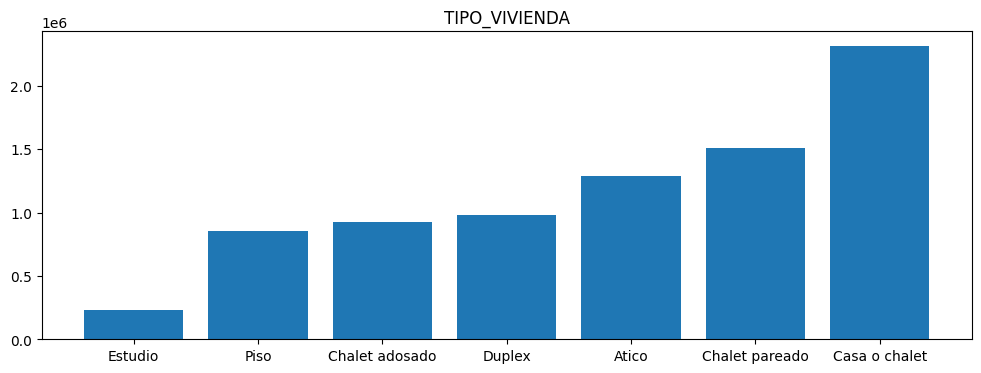

In [45]:
column = 'tipo_vivienda'
df_tmp = df.groupby(column)['precio'].mean().reset_index().sort_values('precio')
print(df_tmp)

plt.figure(figsize=(12, 4))
plt.bar(df_tmp[column], df_tmp['precio'])
plt.title(df_tmp.columns[0].upper())
plt.show()


In [46]:
column = 'tipo_vivienda'
df_tmp = df.groupby(column)['precio'].count().reset_index().sort_values('precio')
print(df_tmp)

    tipo_vivienda  precio
3  Chalet pareado     117
1   Casa o chalet     159
2  Chalet adosado     225
5         Estudio     269
4          Duplex     364
0           Atico     592
6            Piso    8187


In [47]:
df.pivot_table(index='tipo_vivienda', columns='ciudad', aggfunc='size', fill_value=0)


ciudad,Alcalá de Henares,Madrid,Móstoles
tipo_vivienda,,,
Atico,6,583,3
Casa o chalet,10,138,11
Chalet adosado,20,138,67
Chalet pareado,5,102,10
Duplex,9,353,2
Estudio,5,259,5
Piso,131,7947,109


##### Agrupem ela xalets.

In [48]:
df['tipo_vivienda'] = df['tipo_vivienda'].apply(lambda x: 'Casa/Chalet' if x in ['Casa o chalet', 'Chalet adosado', 'Chalet pareado'] else x)


In [49]:
df.pivot_table(index='tipo_vivienda', columns='ciudad', aggfunc='size', fill_value=0)


ciudad,Alcalá de Henares,Madrid,Móstoles
tipo_vivienda,,,
Atico,6,583,3
Casa/Chalet,35,378,88
Duplex,9,353,2
Estudio,5,259,5
Piso,131,7947,109


  tipo_vivienda        precio
3       Estudio  2.336065e+05
4          Piso  8.522262e+05
2        Duplex  9.797751e+05
0         Atico  1.291065e+06
1   Casa/Chalet  1.503359e+06


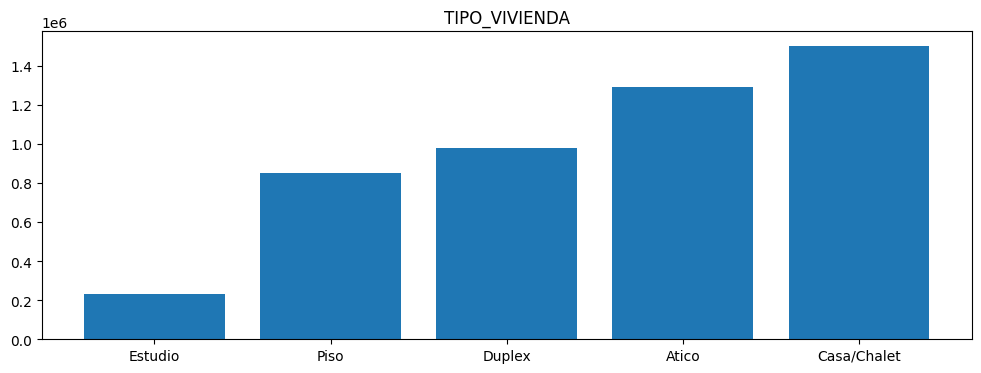

In [50]:
column = 'tipo_vivienda'
df_tmp = df.groupby(column)['precio'].mean().reset_index().sort_values('precio')
print(df_tmp)

plt.figure(figsize=(12, 4))
plt.bar(df_tmp[column], df_tmp['precio'])
plt.title(df_tmp.columns[0].upper())
plt.show()


In [51]:
df['tipo_vivienda'].unique()

array(['Casa/Chalet', 'Piso', 'Duplex', 'Atico', 'Estudio'], dtype=object)

## Backup

In [52]:
df_orginal_1 = df.copy()

In [53]:
#df_orginal_1[ df_orginal_1['tipo_vivienda']=='Duplex' ].head()

In [54]:
#df = df_orginal_1.copy()

In [55]:
from sklearn.preprocessing import OrdinalEncoder

orden_personalizado = [['Estudio',
                         'Piso',
                         'Duplex',
                         'Atico',
                         'Casa/Chalet']]
ordinal_encoder = OrdinalEncoder(categories=orden_personalizado)

df['tipo_vivienda'] = ordinal_encoder.fit_transform(df[['tipo_vivienda']])


In [56]:
df.head(3)

,sku,metros_cuadrados,calle,barrio,distrito,ciudad,tipo_vivienda,habitaciones,ban,planta,terraza,balcon,ascensor,casa_plantas,estado_obra,caracteristicas_basicas,precio,precio_m2_barrio,precio_m2_distrito,precio_m2_calle
0,100848270,237,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,4.0,4,1,4,0,0,0,1,No declara,"['Casa o chalet', '237 m² construidos, 232 m² ...",616300,2.236608,2.236608,2.717073
1,105997257,91,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,1.0,2,1,2,1,1,0,0,No declara,"['91 m² construidos, 73 m² útiles', '2 habitac...",274900,2.236608,2.236608,2.717073
2,106297757,268,El pilar - bripac,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,4.0,4,3,4,0,0,0,1,No declara,"['Chalet adosado', '268 m² construidos, 254 m²...",519000,2.236608,2.236608,1.948505


In [57]:
# Guardar la tabla tipo de vivienda
df_tipo_vivienda = pd.DataFrame({'tipo_vivienda': orden_personalizado[0]}).reset_index()
df_tipo_vivienda = df_tipo_vivienda[['tipo_vivienda','index']]
df_tipo_vivienda


,tipo_vivienda,index
0,Estudio,0
1,Piso,1
2,Duplex,2
3,Atico,3
4,Casa/Chalet,4


In [58]:
df_tipo_vivienda.to_csv('/content/drive/MyDrive/IgniteAI/Proyecto_Inmobiliaria/03. Datos/Madrid/Tablas LU/LU tipo de vivienda.csv', index=False, encoding='utf-8')

#### **Variable Habitaciones**

[ 4  2  5  3  6  7  1 10  8  0 12  9 19 13 15 24 11 14]
    habitaciones        precio
0              0  2.657078e+05
1              1  3.405751e+05
2              2  6.178391e+05
3              3  8.511818e+05
4              4  1.470780e+06
5              5  2.213204e+06
6              6  2.283031e+06
7              7  2.386186e+06
8              8  1.630645e+06
9              9  3.043462e+06
10            10  3.612692e+06
11            11  3.116667e+06
12            12  1.571875e+06
13            13  3.540000e+06
14            14  1.000000e+07
15            15  3.900000e+06
16            19  2.600000e+06
17            24  2.600000e+06


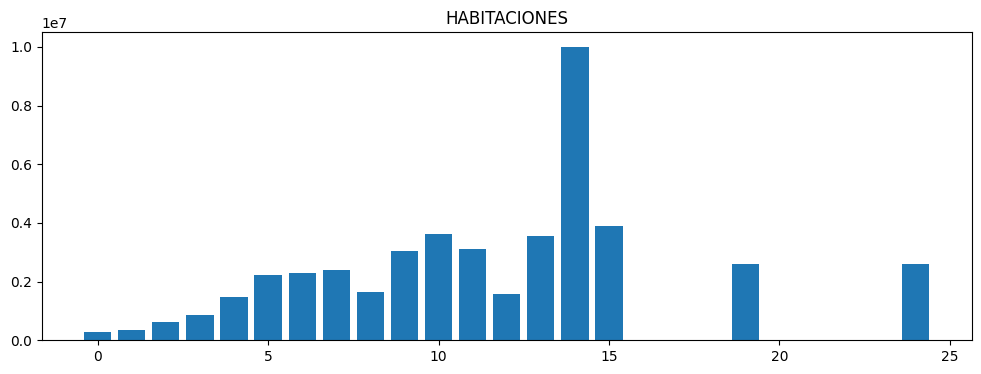

In [59]:
dataframe = df.copy()
column = 'habitaciones'

print(dataframe[column].unique())

df_tmp = dataframe.groupby(column)['precio'].mean().reset_index().sort_values(column)
print(df_tmp)

plt.figure(figsize=(12, 4))
plt.bar(df_tmp[column], df_tmp['precio'])
plt.title(df_tmp.columns[0].upper())
plt.show()


Aquelles vivendes que tinguin més de 8 habitacions, els hi assignem 8 habitacions.

In [60]:
df['tmp'] = None
df['tmp'] = df['habitaciones'].apply(lambda x: 8 if x>8 else x)
df['habitaciones'] = df['tmp']
df = df.drop(['tmp'], axis=1)


[4 2 5 3 6 7 1 8 0]
   habitaciones        precio
0             0  2.657078e+05
1             1  3.405751e+05
2             2  6.178391e+05
3             3  8.511818e+05
4             4  1.470780e+06
5             5  2.213204e+06
6             6  2.283031e+06
7             7  2.386186e+06
8             8  2.555679e+06


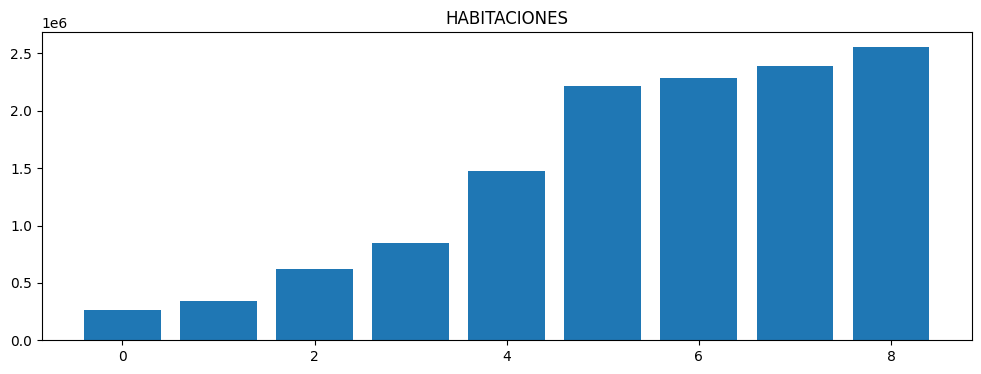

In [61]:
dataframe = df.copy()
column = 'habitaciones'

print(dataframe[column].unique())

df_tmp = dataframe.groupby(column)['precio'].mean().reset_index().sort_values(column)
print(df_tmp)

plt.figure(figsize=(12, 4))
plt.bar(df_tmp[column], df_tmp['precio'])
plt.title(df_tmp.columns[0].upper())
plt.show()


Si l'usuari ingressa un numero major de u habitacions, se li assignarà 8.


#### **Variable Baños**

[ 1  3  2  4  5  0  8  6 13 15 10  9 17  7]
    ban        precio
0     0  1.261556e+06
1     1  3.009602e+05
2     2  7.694014e+05
3     3  1.396388e+06
4     4  2.401549e+06
5     5  3.389188e+06
6     6  4.225988e+06
7     7  2.949737e+06
8     8  2.751875e+06
9     9  2.035000e+06
10   10  3.800000e+06
11   13  3.540000e+06
12   15  3.900000e+06
13   17  2.600000e+06


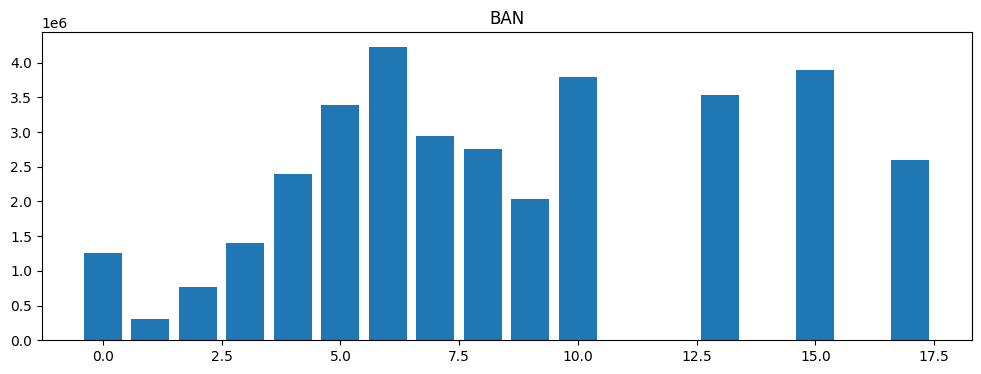

In [62]:
dataframe = df.copy()
column = 'ban'

print(dataframe[column].unique())

df_tmp = dataframe.groupby(column)['precio'].mean().reset_index().sort_values(column)
print(df_tmp)

plt.figure(figsize=(12, 4))
plt.bar(df_tmp[column], df_tmp['precio'])
plt.title(df_tmp.columns[0].upper())
plt.show()


Ens quedem aquells immobles que tinguin menys de 9 lavavos.

In [63]:
df = df[df['ban'] < 9]
df = df.reset_index(drop=True)

In [64]:
df[df['ban'] == 0].count()

,0
sku,16
metros_cuadrados,16
calle,16
barrio,16
distrito,16
ciudad,16
tipo_vivienda,16
habitaciones,16
ban,16
planta,16


In [65]:
df['tmp'] = None
df['tmp'] = df['ban'].apply(lambda x: 1 if x==0 else x)
df['ban'] = df['tmp']
df = df.drop(['tmp'], axis=1)


[1 3 2 4 5 8 6 7]
   ban        precio
0    1  3.047930e+05
1    2  7.694014e+05
2    3  1.396388e+06
3    4  2.401549e+06
4    5  3.389188e+06
5    6  4.225988e+06
6    7  2.949737e+06
7    8  2.751875e+06


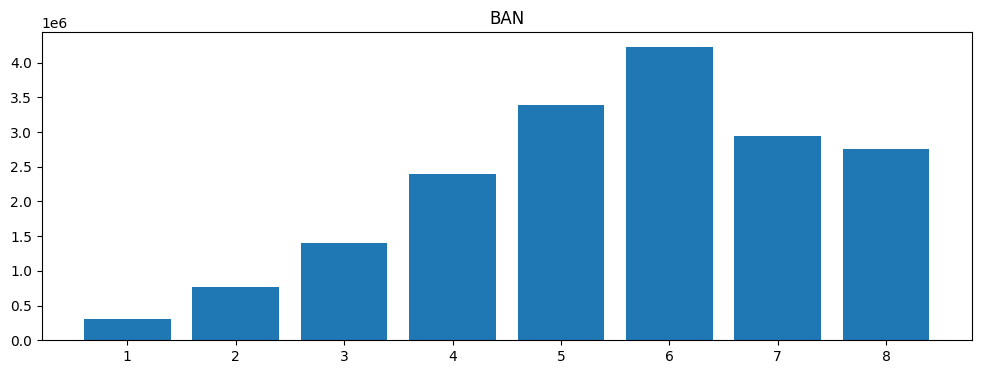

In [66]:
dataframe = df.copy()
column = 'ban'

print(dataframe[column].unique())

df_tmp = dataframe.groupby(column)['precio'].mean().reset_index().sort_values(column)
print(df_tmp)

plt.figure(figsize=(12, 4))
plt.bar(df_tmp[column], df_tmp['precio'])
plt.title(df_tmp.columns[0].upper())
plt.show()


Si l'usuari ingressa un numero major de 8 lavavos, se li assignarà 8.

#### **Variable Planta**

In [67]:
column = 'planta'
df[column].unique()

array(['4', '2', '5', '3', '6', '7', '1', '10', '8', 'Bajo',
       'Entreplanta', 'Semi-sótano', '12', '-1', 'Sótano', '9',
       'exterior', 'interior', '11', '14'], dtype=object)

         planta        precio  tipo_vivienda
16  Semi-sótano  1.717875e+05              8
15  Entreplanta  1.838333e+05              9
0            -1  2.105000e+05              4
14         Bajo  2.687323e+05            131
17       Sótano  3.151429e+05              7
1             1  3.973091e+05           1449
6             2  6.112395e+05           2822
19     interior  8.390000e+05              1
7             3  8.426933e+05           3225
18     exterior  1.020012e+06             10
4            12  1.395833e+06              3
8             4  1.434840e+06           1407
12            8  1.555625e+06             32
9             5  2.103150e+06            542
10            6  2.219461e+06            165
11            7  2.286348e+06             58
13            9  2.922500e+06             14
3            11  3.262500e+06              4
2            10  3.328143e+06             14
5            14  1.000000e+07              1


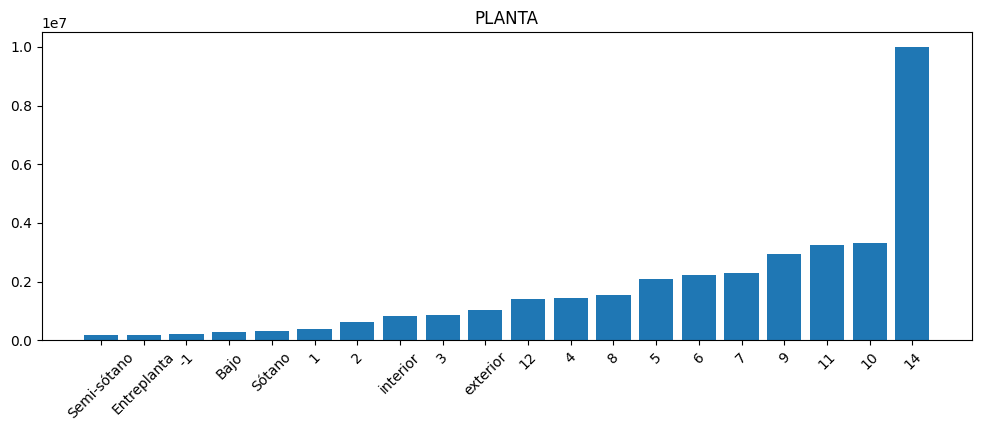

In [68]:
column = 'planta'

df_tmp = df.groupby(column).agg({'precio':'mean', 'tipo_vivienda':'count'}).reset_index().sort_values('precio')
print(df_tmp)

plt.figure(figsize=(12, 4))
plt.bar(df_tmp[column], df_tmp['precio'])
plt.title(df_tmp.columns[0].upper())
plt.xticks(rotation=45)
plt.show()


In [69]:
df[ df['planta'] == 'exterior'].groupby('ciudad')['sku'].count()

,sku
ciudad,
Madrid,9
Móstoles,1


In [70]:
df[ (df['planta'] == 'exterior') & (df['ciudad'] == 'Madrid') ].groupby('distrito')['precio'].mean()


,precio
distrito,
Centro,1722000.0
Salamanca,395000.0
Tetuán,300557.5


In [71]:
df[df['planta']=='interior'].count()

,0
sku,1
metros_cuadrados,1
calle,1
barrio,1
distrito,1
ciudad,1
tipo_vivienda,1
habitaciones,1
ban,1
planta,1


Eliminem les plantes "exteriors" i les "interiors"

In [72]:
df = df[ df['planta'] != 'exterior']
df = df[ df['planta'] != 'interior']

In [73]:
print(df['planta'].unique())


['4' '2' '5' '3' '6' '7' '1' '10' '8' 'Bajo' 'Entreplanta' 'Semi-sótano'
 '12' '-1' 'Sótano' '9' '11' '14']


In [74]:
df

,sku,metros_cuadrados,calle,barrio,distrito,ciudad,tipo_vivienda,habitaciones,ban,planta,terraza,balcon,ascensor,casa_plantas,estado_obra,caracteristicas_basicas,precio,precio_m2_barrio,precio_m2_distrito,precio_m2_calle
0,100848270,237,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,4.0,4,1,4,0,0,0,1,No declara,"['Casa o chalet', '237 m² construidos, 232 m² ...",616300,2.236608,2.236608,2.717073
1,105997257,91,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,1.0,2,1,2,1,1,0,0,No declara,"['91 m² construidos, 73 m² útiles', '2 habitac...",274900,2.236608,2.236608,2.717073
2,106297757,268,El pilar - bripac,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,4.0,4,3,4,0,0,0,1,No declara,"['Chalet adosado', '268 m² construidos, 254 m²...",519000,2.236608,2.236608,1.948505
3,106183720,372,El pilar - bripac,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,4.0,5,3,5,0,0,0,4,No declara,"['Chalet adosado', '4 plantas', '372 m² constr...",569000,2.236608,2.236608,1.948505
4,106538802,95,El pilar - bripac,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,1.0,3,2,3,1,0,1,0,No declara,"['95 m² construidos, 90 m² útiles', '3 habitac...",398000,2.236608,2.236608,1.948505
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9900,106642490,109,Calle rio duero,Suroeste,Suroeste,Móstoles,1.0,3,2,Bajo,0,0,1,0,No declara,"['109 m² construidos', '3 habitaciones', '2 ba...",335000,2.828129,2.828129,3.073394
9901,106464447,121,Calle río ebro,Suroeste,Suroeste,Móstoles,1.0,3,2,10,0,0,1,0,No declara,"['121 m² construidos', '3 habitaciones', '2 ba...",329000,2.828129,2.828129,2.719008
9902,106325632,120,Calle río odiel,Suroeste,Suroeste,Móstoles,1.0,4,2,8,0,0,1,0,No declara,"['120 m² construidos, 96 m² útiles', '4 habita...",410000,2.828129,2.828129,3.416667
9903,101086503,99,Calle río segre,Suroeste,Suroeste,Móstoles,1.0,3,1,4,1,0,1,0,No declara,"['99 m² construidos', '3 habitaciones', '1 bañ...",256000,2.828129,2.828129,2.585859


In [75]:
import numpy as np

df['npiso'] = None

# Reset the index before iterating to avoid KeyErrors
df = df.reset_index(drop=True)

for i in np.arange(0, len(df)):
    #print(i)
    if df.loc[i, 'planta'] == 'Sótano':
        val = '-2'
    elif df.loc[i, 'planta'] == 'Semi-sótano':
        val = '-2'
    elif df.loc[i, 'planta'] == 'Entreplanta':
        val ='-1'
    elif df.loc[i, 'planta'] == 'Bajo':
        val ='0'
    else:
        val = df.loc[i, 'planta']
    df.loc[i, 'npiso'] = val

In [76]:
tb_planta = pd.DataFrame({  'planta': ['Semi-sótano', 'Entreplanta', 'Bajo', '1', '2', '3', '4', '5', '6', '7', '8 o más'],
                            'valor' : [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]
                         })
tb_planta


,planta,valor
0,Semi-sótano,-2
1,Entreplanta,-1
2,Bajo,0
3,1,1
4,2,2
5,3,3
6,4,4
7,5,5
8,6,6
9,7,7


In [77]:
tb_planta.to_csv('/content/drive/MyDrive/IgniteAI/Proyecto_Inmobiliaria/03. Datos/Madrid/Tablas LU/LU de plantas.csv', index=False, encoding='utf-8')

In [78]:
df['planta'] = df['npiso']
df = df.drop(['npiso'], axis=1)
df.head(3)


,sku,metros_cuadrados,calle,barrio,distrito,ciudad,tipo_vivienda,habitaciones,ban,planta,terraza,balcon,ascensor,casa_plantas,estado_obra,caracteristicas_basicas,precio,precio_m2_barrio,precio_m2_distrito,precio_m2_calle
0,100848270,237,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,4.0,4,1,4,0,0,0,1,No declara,"['Casa o chalet', '237 m² construidos, 232 m² ...",616300,2.236608,2.236608,2.717073
1,105997257,91,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,1.0,2,1,2,1,1,0,0,No declara,"['91 m² construidos, 73 m² útiles', '2 habitac...",274900,2.236608,2.236608,2.717073
2,106297757,268,El pilar - bripac,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,4.0,4,3,4,0,0,0,1,No declara,"['Chalet adosado', '268 m² construidos, 254 m²...",519000,2.236608,2.236608,1.948505


['4' '2' '5' '3' '6' '7' '1' '10' '8' '0' '-1' '-2' '12' '9' '11' '14']
   planta        precio  tipo_vivienda
0      -1  1.920385e+05             13
1      -2  2.386867e+05             15
2       0  2.687323e+05            131
3       1  3.973091e+05           1449
8       2  6.112395e+05           2822
9       3  8.426933e+05           3225
6      12  1.395833e+06              3
10      4  1.434840e+06           1407
14      8  1.555625e+06             32
11      5  2.103150e+06            542
12      6  2.219461e+06            165
13      7  2.286348e+06             58
15      9  2.922500e+06             14
5      11  3.262500e+06              4
4      10  3.328143e+06             14
7      14  1.000000e+07              1


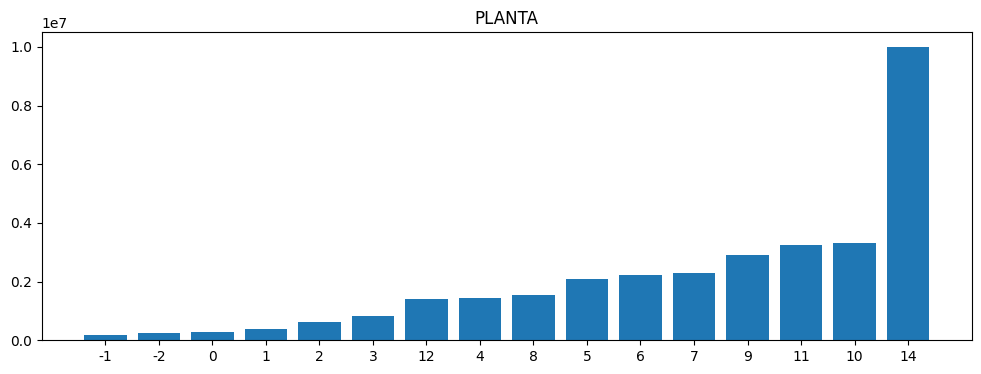

In [79]:
column = 'planta'
print(df[column].unique())

df_tmp = df.groupby(column).agg({'precio':'mean', 'tipo_vivienda':'count'}).reset_index().sort_values('precio')
print(df_tmp)

plt.figure(figsize=(12, 4))
plt.bar(df_tmp[column], df_tmp['precio'])
plt.title(df_tmp.columns[0].upper())
plt.show()



In [80]:
df['planta'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 9895 entries, 0 to 9894
Series name: planta
Non-Null Count  Dtype 
--------------  ----- 
9895 non-null   object
dtypes: object(1)
memory usage: 77.4+ KB


In [81]:
df['planta'] = df['planta'].apply(lambda x: int(x))


In [82]:
df['planta'] = df['planta'].apply(lambda x: 0 if x<1 else x)


[ 4  2  5  3  6  7  1 10  8  0 12  9 11 14]
    planta        precio
0        0  2.596273e+05
1        1  3.973091e+05
2        2  6.112395e+05
3        3  8.426933e+05
4        4  1.434840e+06
5        5  2.103150e+06
6        6  2.219461e+06
7        7  2.286348e+06
8        8  1.555625e+06
9        9  2.922500e+06
10      10  3.328143e+06
11      11  3.262500e+06
12      12  1.395833e+06
13      14  1.000000e+07


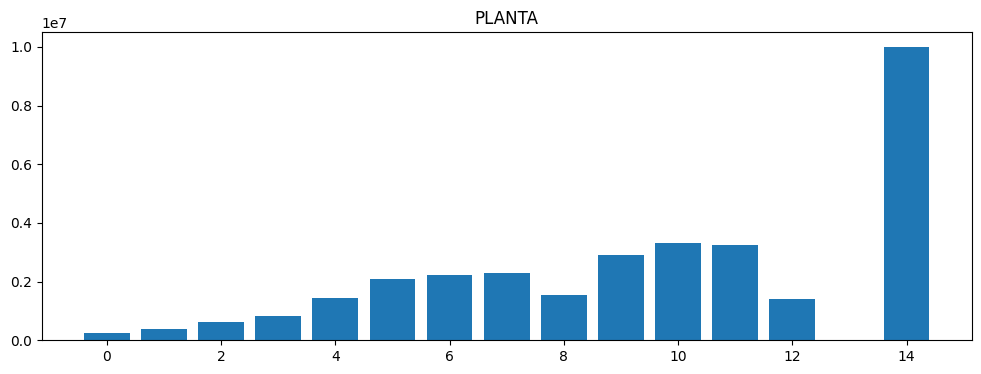

In [83]:
column = 'planta'
print(df[column].unique())

df_tmp = df.groupby(column)['precio'].mean().reset_index().sort_values(column)
print(df_tmp)

plt.figure(figsize=(12, 4))
plt.bar(df_tmp[column], df_tmp['precio'])
plt.title(df_tmp.columns[0].upper())
plt.show()


In [84]:
df[df['planta'] == 14]


,sku,metros_cuadrados,calle,barrio,distrito,ciudad,tipo_vivienda,habitaciones,ban,planta,terraza,balcon,ascensor,casa_plantas,estado_obra,caracteristicas_basicas,precio,precio_m2_barrio,precio_m2_distrito,precio_m2_calle
3259,97274953,849,Darro,El Viso,Chamartín,Madrid,4.0,8,5,14,0,0,0,3,No declara,"['Casa o chalet independiente', '3 plantas', '...",10000000,9.004504,7.543336,11.778563


In [85]:
df = df[df['planta'] != 14]
#df = df.reset_index(drop=True)


In [86]:
df['planta'] = df['planta'].apply(lambda x: 8 if x> 8 else x)

[4 2 5 3 6 7 1 8 0]
   planta        precio  tipo_vivienda
0       0  2.596273e+05            159
1       1  3.973091e+05           1449
2       2  6.112395e+05           2822
3       3  8.426933e+05           3225
4       4  1.434840e+06           1407
5       5  2.103150e+06            542
6       6  2.219461e+06            165
7       7  2.286348e+06             58
8       8  2.306366e+06             67


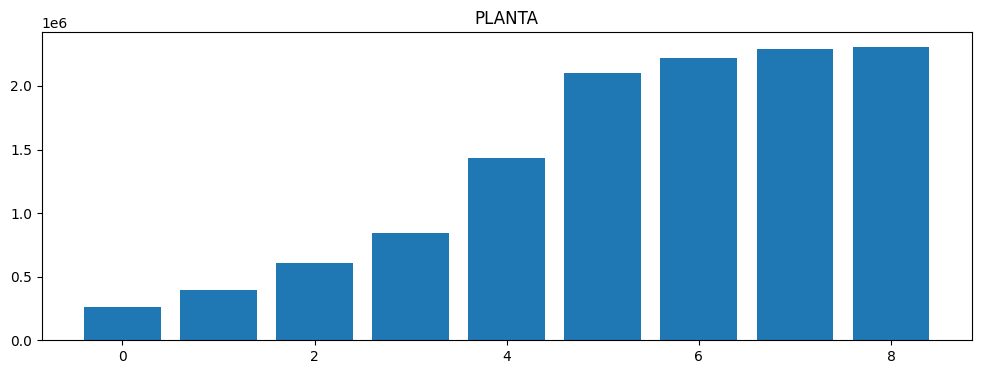

In [87]:
column = 'planta'
print(df[column].unique())

df_tmp = df.groupby(column).agg({'precio':'mean', 'tipo_vivienda':'count'}).reset_index().sort_values(column)
print(df_tmp)

plt.figure(figsize=(12, 4))
plt.bar(df_tmp[column], df_tmp['precio'])
plt.title(df_tmp.columns[0].upper())
plt.show()


Per a plantes majors a 8, s'hi assignarà 8.

#### **Variable Terraza**

[0 1]
   terraza         precio
0        0  863637.282120
1        1  967789.956023


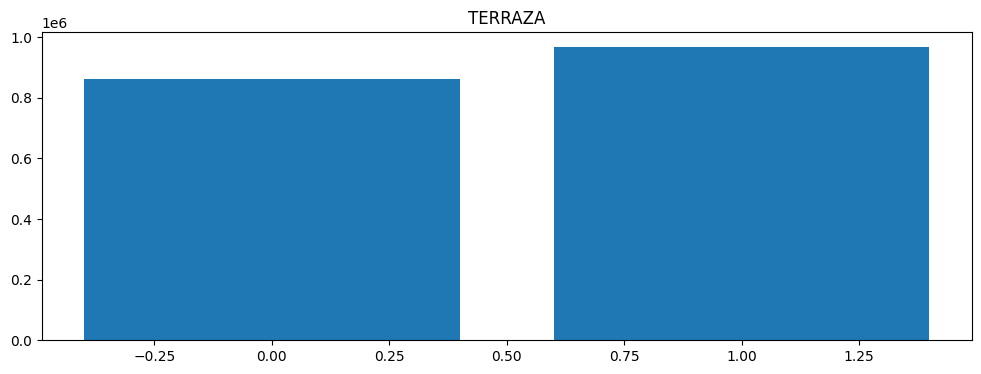

In [88]:
dataframe = df.copy()
column = 'terraza'

print(dataframe[column].unique())

df_tmp = dataframe.groupby(column)['precio'].mean().reset_index().sort_values(column)
print(df_tmp)

plt.figure(figsize=(12, 4))
plt.bar(df_tmp[column], df_tmp['precio'])
plt.title(df_tmp.columns[0].upper())
plt.show()


#### **Variable Balcon**

[0 1]
   balcon        precio
0       0  7.947863e+05
1       1  1.337913e+06


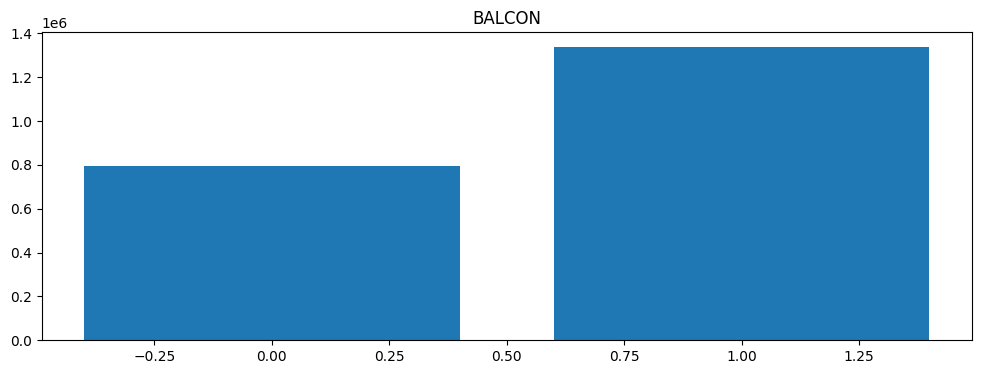

In [89]:
dataframe = df.copy()
column = 'balcon'

print(dataframe[column].unique())

df_tmp = dataframe.groupby(column)['precio'].mean().reset_index().sort_values(column)
print(df_tmp)

plt.figure(figsize=(12, 4))
plt.bar(df_tmp[column], df_tmp['precio'])
plt.title(df_tmp.columns[0].upper())
plt.show()


#### **Variable Ascensor**

[0 1]
   ascensor        precio
0         0  5.234520e+05
1         1  1.047600e+06


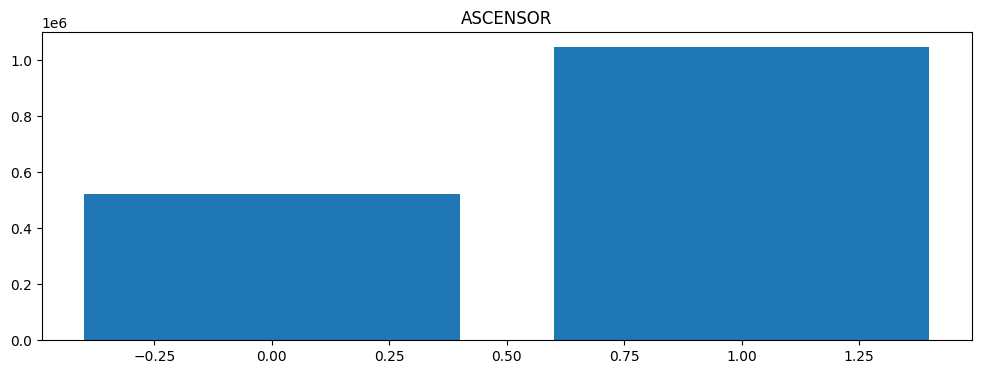

In [90]:
dataframe = df.copy()
column = 'ascensor'

print(dataframe[column].unique())

df_tmp = dataframe.groupby(column)['precio'].mean().reset_index().sort_values(column)
print(df_tmp)

plt.figure(figsize=(12, 4))
plt.bar(df_tmp[column], df_tmp['precio'])
plt.title(df_tmp.columns[0].upper())
plt.show()


#### **Variable casa_plantas**

[1 0 4 3 2 5]
   casa_plantas        precio
0             0  8.654013e+05
1             1  1.688358e+06
2             2  8.038339e+05
3             3  1.420805e+06
4             4  1.615361e+06
5             5  3.293600e+06


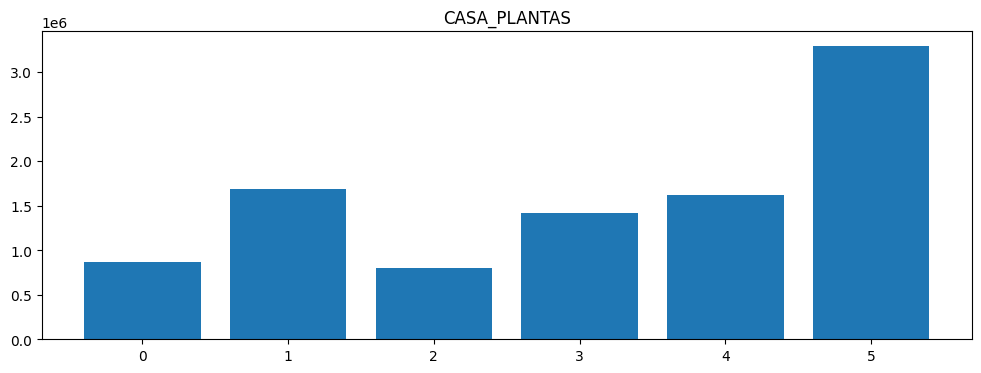

In [91]:
dataframe = df.copy()
column = 'casa_plantas'

print(dataframe[column].unique())

df_tmp = dataframe.groupby(column)['precio'].mean().reset_index().sort_values(column)
print(df_tmp)

plt.figure(figsize=(12, 4))
plt.bar(df_tmp[column], df_tmp['precio'])
plt.title(df_tmp.columns[0].upper())
plt.show()


In [92]:
df.head(3)

,sku,metros_cuadrados,calle,barrio,distrito,ciudad,tipo_vivienda,habitaciones,ban,planta,terraza,balcon,ascensor,casa_plantas,estado_obra,caracteristicas_basicas,precio,precio_m2_barrio,precio_m2_distrito,precio_m2_calle
0,100848270,237,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,4.0,4,1,4,0,0,0,1,No declara,"['Casa o chalet', '237 m² construidos, 232 m² ...",616300,2.236608,2.236608,2.717073
1,105997257,91,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,1.0,2,1,2,1,1,0,0,No declara,"['91 m² construidos, 73 m² útiles', '2 habitac...",274900,2.236608,2.236608,2.717073
2,106297757,268,El pilar - bripac,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,4.0,4,3,4,0,0,0,1,No declara,"['Chalet adosado', '268 m² construidos, 254 m²...",519000,2.236608,2.236608,1.948505


Per a les vivendes que son cases, les hi assignem un nombre de plantes.<br>
Si no es una casa, se li assigna un 0.

In [93]:
df.groupby('tipo_vivienda')['casa_plantas'].sum()

,casa_plantas
tipo_vivienda,
0.0,0
1.0,0
2.0,0
3.0,0
4.0,1344


#### **Variable Estado de la Obra**

                  estado_obra        precio
1                  Obra nueva  6.343397e+05
2    Segunda mano/buen estado  6.479810e+05
3  Segunda mano/para reformar  6.592710e+05
0                  No declara  1.049520e+06


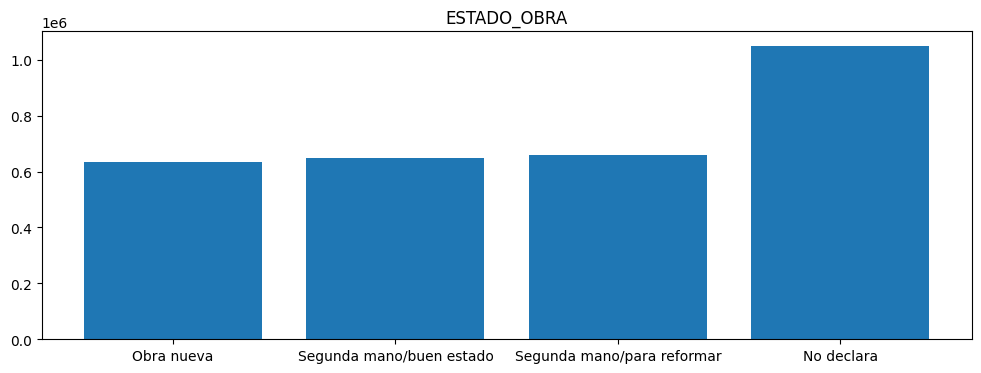

In [94]:
column = 'estado_obra'
df_tmp = df.groupby(column)['precio'].mean().reset_index().sort_values('precio')
print(df_tmp)

plt.figure(figsize=(12, 4))
plt.bar(df_tmp[column], df_tmp['precio'])
plt.title(df_tmp.columns[0].upper())
plt.show()


In [95]:
pd.crosstab(df['tipo_vivienda'], df['estado_obra'], margins=True)

estado_obra,No declara,Obra nueva,Segunda mano/buen estado,Segunda mano/para reformar,All
tipo_vivienda,,,,,
0.0,84,2,162,19,267
1.0,4748,54,2875,496,8173
2.0,248,7,101,8,364
3.0,536,0,48,7,591
4.0,499,0,0,0,499
All,6115,63,3186,530,9894


Nomes les vivendes amb estat "Segunda mano/para reformar" son els que necessiten reforma, els altres tipos de vivendes no declaren o no requieren.

In [96]:
#df['estado_obra'].apply(lambda x: int(1) if x=='Segunda mano/para reformar' else int(0))


                  estado_obra        precio
1                  Obra nueva  6.343397e+05
2    Segunda mano/buen estado  6.479810e+05
3  Segunda mano/para reformar  6.592710e+05
0                  No declara  1.010791e+06


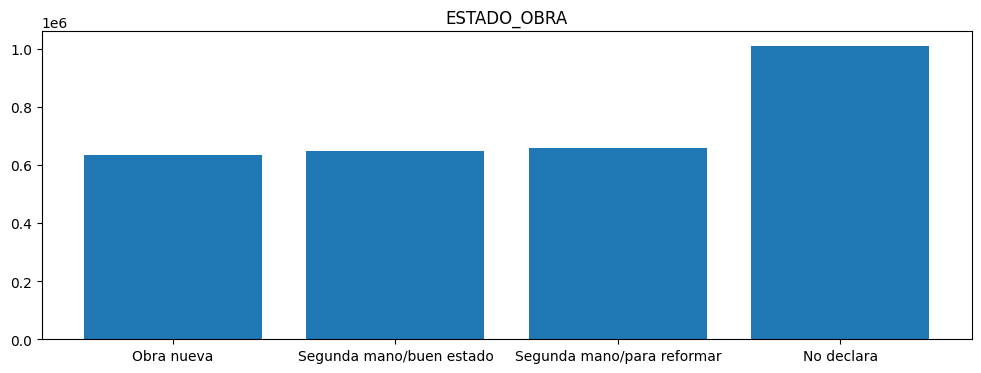

In [97]:
column = 'estado_obra'
df_tmp = df[ df['tipo_vivienda']!=4 ].groupby(column)['precio'].mean().reset_index().sort_values('precio')
print(df_tmp)

plt.figure(figsize=(12, 4))
plt.bar(df_tmp[column], df_tmp['precio'])
plt.title(df_tmp.columns[0].upper())
plt.show()


In [98]:
df[ df['tipo_vivienda']!=4 ].head(1)

,sku,metros_cuadrados,calle,barrio,distrito,ciudad,tipo_vivienda,habitaciones,ban,planta,terraza,balcon,ascensor,casa_plantas,estado_obra,caracteristicas_basicas,precio,precio_m2_barrio,precio_m2_distrito,precio_m2_calle
1,105997257,91,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,1.0,2,1,2,1,1,0,0,No declara,"['91 m² construidos, 73 m² útiles', '2 habitac...",274900,2.236608,2.236608,2.717073


In [99]:
df[ df['tipo_vivienda']!=4 ].pivot_table(index='tipo_vivienda', columns='estado_obra', values='precio', aggfunc='mean')


estado_obra,No declara,Obra nueva,Segunda mano/buen estado,Segunda mano/para reformar
tipo_vivienda,,,,
0.0,2.698405e+05,340000.000000,2.136305e+05,2.155474e+05
1.0,9.862038e+05,674470.370370,6.600166e+05,6.679178e+05
2.0,1.190792e+06,408857.142857,5.466000e+05,4.066250e+05
3.0,1.261422e+06,NaN,1.606354e+06,1.539714e+06


- tipo_vivienda	index
- 0	Estudio	0
- 1	Piso	1
- 2	Duplex	2
- 3	Atico	3
- 4	Casa/Chalet	4


In [100]:
df['estado_obra_flag'] = df['estado_obra'].map({
    'Segunda mano/para reformar': 0,
    'Segunda mano/buen estado': 1,
    'Obra nueva': 2,
    'No declara': 1
})

## Conclusiones
- No se puede utilizar las 3 divisiones: obra nueva, buen estado, para reformar.
- Porque las viviendas que requieren reforma tienen precio medio superior. Los no declara paracen ser buen estado.
## Solucion
- Mantener Segunda mano/para reformar = 0 y el resto 1.
- o imputar por fuera del modelo.


In [101]:
'''
df['tmp'] = None
df['tmp'] = df['estado_obra'].apply(lambda x: int(0) if x=='Segunda mano/para reformar' else int(1))
df['estado_obra_flag'] = df['tmp']
df = df.drop(['tmp'], axis=1)
'''


"\ndf['tmp'] = None\ndf['tmp'] = df['estado_obra'].apply(lambda x: int(0) if x=='Segunda mano/para reformar' else int(1))\ndf['estado_obra_flag'] = df['tmp']\ndf = df.drop(['tmp'], axis=1)\n"

In [102]:
df['estado_obra_flag'].unique()

array([1, 0, 2])

In [103]:
df['estado_obra'] = df['estado_obra_flag']
df = df.drop(['estado_obra_flag'], axis=1)


In [104]:
pd.crosstab(df['tipo_vivienda'], df['estado_obra'], margins=True)

estado_obra,0,1,2,All
tipo_vivienda,,,,
0.0,19,246,2,267
1.0,496,7623,54,8173
2.0,8,349,7,364
3.0,7,584,0,591
4.0,0,499,0,499
All,530,9301,63,9894


   estado_obra         precio
2            2  634339.682540
0            0  659271.003774
1            1  911975.199226


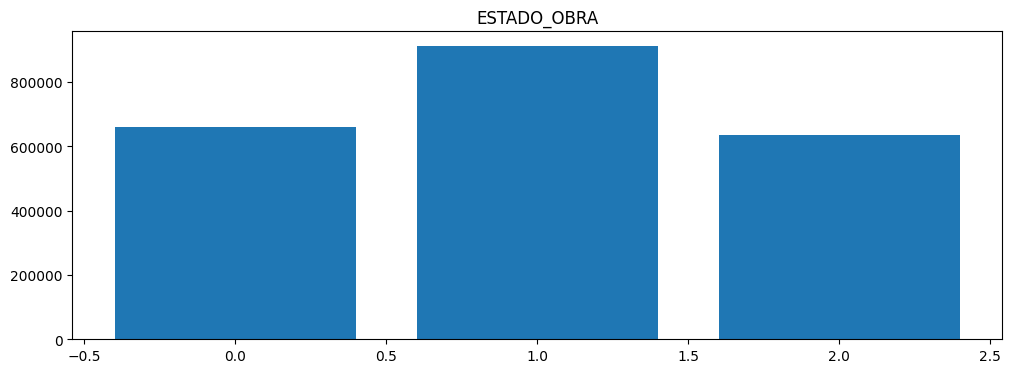

In [105]:
column = 'estado_obra'
df_tmp = df.groupby(column)['precio'].mean().reset_index().sort_values('precio')
print(df_tmp)

plt.figure(figsize=(12, 4))
plt.bar(df_tmp[column], df_tmp['precio'])
plt.title(df_tmp.columns[0].upper())
plt.show()


In [106]:
'''
tb_estado = pd.DataFrame({'estado': ['Para reformar', 'Buen estado'], 'valor': [0, 1]})
tb_estado
'''
tb_estado = pd.DataFrame({'estado': ['Para reformar', 'Buen estado', 'Obra nueva'], 'valor': [0, 1, 2]})
tb_estado


,estado,valor
0,Para reformar,0
1,Buen estado,1
2,Obra nueva,2


In [107]:
tb_estado.to_csv("/content/drive/MyDrive/IgniteAI/Proyecto_Inmobiliaria/03. Datos/Madrid/Tablas LU/LU Estat de l'imoble.csv", index=False, encoding='utf-8')


In [ ]:
df.head(2)

,sku,metros_cuadrados,calle,barrio,distrito,ciudad,tipo_vivienda,habitaciones,ban,planta,terraza,balcon,ascensor,casa_plantas,estado_obra,caracteristicas_basicas,precio,precio_m2_barrio,precio_m2_distrito,precio_m2_calle
0,100848270,237,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,4.0,4,1,4,0,0,0,1,1,"['Casa o chalet', '237 m² construidos, 232 m² ...",616300,2.236608,2.236608,2.717073
1,105997257,91,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,1.0,2,1,2,1,1,0,0,1,"['91 m² construidos, 73 m² útiles', '2 habitac...",274900,2.236608,2.236608,2.717073


In [ ]:
df.to_csv("/content/drive/MyDrive/IgniteAI/Proyecto_Inmobiliaria/03. Datos/Madrid/Tablas Transformadas/TF Dades EDA.csv")